In [84]:
import torch
from torch import nn
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T

t2img = T.ToPILImage()

In [85]:
class DownConv2(nn.Module):
    def __init__(self, chin, chout, kernel_size):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=chin, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
            nn.Conv2d(in_channels=chout, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
        )
        self.mp = nn.MaxPool2d(kernel_size=2, return_indices=True)
        
    def forward(self, x):
        y = self.seq(x)
        pool_shape = y.shape
        y, indices = self.mp(y)
        return y, indices, pool_shape

class DownConv3(nn.Module):
    def __init__(self, chin, chout, kernel_size):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=chin, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
            nn.Conv2d(in_channels=chout, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
            nn.Conv2d(in_channels=chout, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
        )
        self.mp = nn.MaxPool2d(kernel_size=2, return_indices=True)
        
    def forward(self, x):
        y = self.seq(x)
        pool_shape = y.shape
        y, indices = self.mp(y)
        return y, indices, pool_shape

class UpConv2(nn.Module):
    def __init__(self, chin, chout, kernel_size):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=chin, out_channels=chin, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chin),
            nn.ReLU(),
            nn.Conv2d(in_channels=chin, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
        )
        self.mup = nn.MaxUnpool2d(kernel_size=2)
        
    def forward(self, x, indices, output_size):
        y = self.mup(x, indices, output_size=output_size)
        y = self.seq(y)
        return y

class UpConv3(nn.Module):
    def __init__(self, chin, chout, kernel_size):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=chin, out_channels=chin, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chin),
            nn.ReLU(),
            nn.Conv2d(in_channels=chin, out_channels=chin, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chin),
            nn.ReLU(),
            nn.Conv2d(in_channels=chin, out_channels=chout, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(chout),
            nn.ReLU(),
        )
        self.mup = nn.MaxUnpool2d(kernel_size=2)
        
    def forward(self, x, indices, output_size):
        y = self.mup(x, indices, output_size=output_size)
        y = self.seq(y)
        return y


class ImageSegmentation(torch.nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.out_channels = 3
        self.bn_input = nn.BatchNorm2d(3)
        self.dc1 = DownConv2(3, 64, kernel_size=kernel_size)
        self.dc2 = DownConv2(64, 128, kernel_size=kernel_size)
        self.dc3 = DownConv3(128, 256, kernel_size=kernel_size)
        self.dc4 = DownConv3(256, 512, kernel_size=kernel_size)
        # self.dc5 = DownConv3(512, 512, kernel_size=kernel_size)
        
        # self.uc5 = UpConv3(512, 512, kernel_size=kernel_size)
        self.uc4 = UpConv3(512, 256, kernel_size=kernel_size)
        self.uc3 = UpConv3(256, 128, kernel_size=kernel_size)
        self.uc2 = UpConv2(128, 64, kernel_size=kernel_size)
        self.uc1 = UpConv2(64, 3, kernel_size=kernel_size)
        
    def forward(self, batch: torch.Tensor):
        x = self.bn_input(batch)
        # x = batch
        # SegNet Encoder
        x, mp1_indices, shape1 = self.dc1(x)
        x, mp2_indices, shape2 = self.dc2(x)
        x, mp3_indices, shape3 = self.dc3(x)
        x, mp4_indices, shape4 = self.dc4(x)
        # Our images are 128x128 in dimension. If we run 4 max pooling
        # operations, we are down to 128/16 = 8x8 activations. If we
        # do another down convolution, we'll be at 4x4 and at that point
        # in time, we may lose too much spatial information as a result
        # of the MaxPooling operation, so we stop at 4 down conv
        # operations.
        # x, mp5_indices, shape5 = self.dc5(x)

        # SegNet Decoder
        # x = self.uc5(x, mp5_indices, output_size=shape5)
        x = self.uc4(x, mp4_indices, output_size=shape4)
        x = self.uc3(x, mp3_indices, output_size=shape3)
        x = self.uc2(x, mp2_indices, output_size=shape2)
        x = self.uc1(x, mp1_indices, output_size=shape1)
        
        return x
    # end def
# end class

def to_device(x):
    if torch.cuda.is_available():
        return x.cuda()
    else:
        return x.cpu()

In [86]:
model = ImageSegmentation(kernel_size=3) # Re-instantiate architecture
model.load_state_dict(torch.load("C:/Users/charl/Downloads/GitHub/YoungWonksLessons/Level5/MachineLearning/Tensorflow/model_weights.pth"))
model.eval()
to_device(model)

ImageSegmentation(
  (bn_input): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dc1): DownConv2(
    (seq): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
    (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dc2): DownConv2(
    (seq): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2

torch.Size([1, 3, 128, 128])
tensor([[[[0.6549, 0.6549, 0.6549,  ..., 0.6392, 0.6392, 0.6392],
          [0.6588, 0.6588, 0.6588,  ..., 0.6392, 0.6353, 0.6353],
          [0.6627, 0.6627, 0.6627,  ..., 0.6353, 0.6314, 0.6314],
          ...,
          [0.4314, 0.4157, 0.4353,  ..., 0.5529, 0.5529, 0.5294],
          [0.4196, 0.4157, 0.4392,  ..., 0.5098, 0.4902, 0.4784],
          [0.4118, 0.4157, 0.4431,  ..., 0.4706, 0.4588, 0.4627]],

         [[0.7412, 0.7412, 0.7412,  ..., 0.7255, 0.7216, 0.7216],
          [0.7451, 0.7451, 0.7451,  ..., 0.7216, 0.7176, 0.7176],
          [0.7490, 0.7490, 0.7490,  ..., 0.7176, 0.7137, 0.7137],
          ...,
          [0.5098, 0.4863, 0.4902,  ..., 0.4627, 0.4353, 0.3843],
          [0.4980, 0.4863, 0.4941,  ..., 0.5020, 0.4824, 0.4314],
          [0.4863, 0.4824, 0.4980,  ..., 0.5216, 0.5294, 0.5020]],

         [[0.4863, 0.4863, 0.4863,  ..., 0.4588, 0.4588, 0.4588],
          [0.4902, 0.4902, 0.4902,  ..., 0.4588, 0.4549, 0.4549],
          [0.

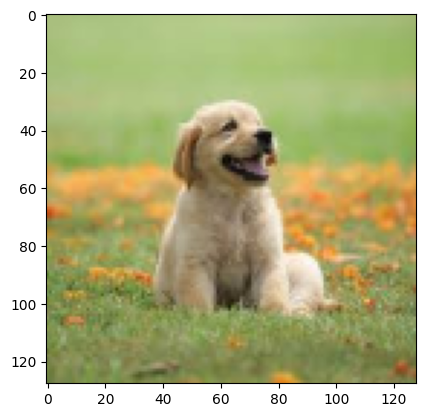

In [87]:
image=cv2.imread("C:/Users/charl/Downloads/GitHub/YoungWonksLessons/Level5/MachineLearning/Tensorflow/dog.jpg")
image=cv2.resize(image,(128,128))
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
image=np.array([image])/255
image=torch.from_numpy(image)
imageList=image.tolist()
list2=[]
for i in range(0,3):
    list2.append([])
    for j in range(0,128):
        list2[i].append([])
        for k in range(0,128):
            list2[i][j].append(imageList[0][j][k][i])
list2=np.array([list2])
list2=torch.from_numpy(list2)
list2=list2.to(torch.float32)
print(list2.shape)
plt.imshow(t2img(list2[0]))
print(list2)
image=list2

tensor([1., 1., 1.,  ..., 1., 1., 1.])


C:\Users\charl\AppData\Local\Temp\ipykernel_5304\3087788660.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_mask=np.absolute(pred_mask*2)


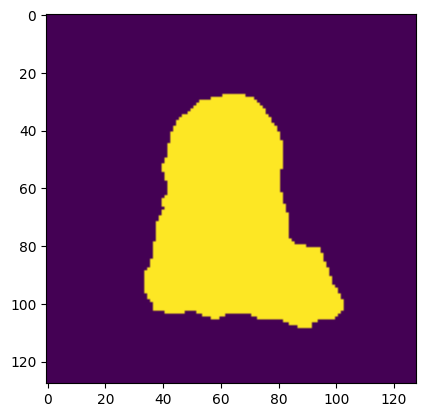

In [95]:
predictions=model(to_device(image))
pred = nn.Softmax(dim=1)(predictions)
pred_labels = pred.argmax(dim=1)
pred_labels = pred_labels.unsqueeze(1)
pred_mask = pred_labels.to(torch.float)
pred_mask=pred_mask/2.0-0.5
pred_mask=np.absolute(pred_mask*2)
print(pred_mask[pred_mask>=1])
#print(predictions)
plt.imshow(t2img(image[0]))
plt.imshow(t2img(pred_mask[0]/2.0))
#0-->1, 0.5-->0, 1-->0.5

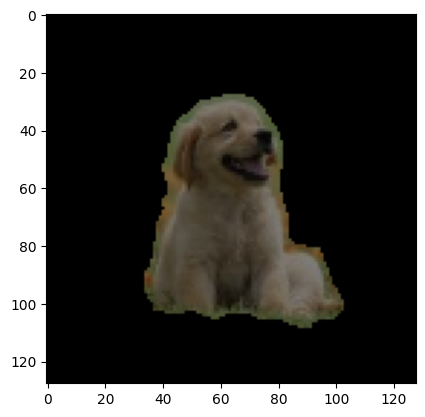

In [93]:
noBackground=torch.mul(image,pred_mask/2.0)
plt.imshow(t2img(noBackground[0]))